# **Basic Seq2Seq Model (Without Attention)**


A **Seq2Seq model** (also known as the **Encoder–Decoder** model) is a neural architecture introduced in 2014** (Sutskever et al., Cho et al.) to transform one sequence into another—even when their lengths differ. Seq2Seq models handle variable-length input and output sequences by using Recurrent Neural Networks (RNNs), LSTMs, or GRUs in both the encoder and decoder. The encoder processes the input sequence step by step, no matter its length, and encodes it into a context vector (or sequence of hidden states in attention-based models). The decoder then generates the output sequence one token at a time until a special <EOS> (end-of-sequence) token is produced, allowing the model to generate variable-length outputs. This design makes Seq2Seq models effective for tasks like machine translation, text summarization, and speech recognition, where both input and output lengths can vary.

Below is an illustrative diagram of the generic Seq2Seq workflow:

<div align='center'>

[![Seq2seq.png](https://i.postimg.cc/Fs7vp2YP/Seq2seq.png)](https://postimg.cc/GHw6hgJY)

*figure: Seq2Seq Model*
</div>


##  How It Works

### 1. Encoder
- Reads the **input sequence** (e.g., words of a sentence) one token at a time.
- Processes the sequence using RNNs (like LSTM, GRU) to produce a **context vector** (a fixed-length summary of the entire input).

### 2. Context Vector
- The encoder’s final hidden state (or concatenated states) acts as a compact representation of the input—the “thought” vector.

### 3. Decoder
- Initialized with the context vector to start generating the **output sequence** (e.g., translated sentence).
- Produces tokens one step at a time, using both:
  - The context vector
  - Its own previously generated tokens


*We will learn encoder-decoder, context vector in details below.*



 # **Encoder–Decoder Architecture**

The encoder–decoder concept arose from the **need to handle variable-length input and output sequences**, such as in machine translation where a sentence in one language must be transformed into another with possibly different length. Traditional neural networks struggled with this because they required fixed-size inputs and outputs. The encoder–decoder framework solved this by using an encoder to compress the entire input sequence into a representation (context vector) and then using a decoder to generate the output sequence step by step from that representation. This idea provided a general framework for sequence-to-sequence tasks.

In deep learning the encoder-decoder model is a type of neural network that is **mainly used for tasks where both the input and output are sequences**. This architecture is used when the input and output sequences are not the same length for example translating a sentence from one language to another, summarizing a paragraph, describing an image with a caption or convert speech into text.

The **Encoder–Decoder architecture** is widely used in **sequence-to-sequence (Seq2Seq)** problems such as:

- **Machine Translation** (e.g., English → French)  
- **Text Summarization** (paragraph → summary)  
- **Image Captioning** (image → description)  
- **Speech Recognition** (speech → text)  

It is particularly useful when **inputs and outputs are of different lengths** and are **not directly aligned**.  

<div align='center'>

[![Seq2seq.png](https://i.postimg.cc/1z6BhbGX/Seq2seq.png)](https://postimg.cc/GBLGv7Sn)

*figure: Encoder Decoder for Seq2Seq Model*
</div>

### Seq2Seq with RNNs  

In the simplest Seq2Seq model, **RNNs** are used in both the encoder and decoder to process sequential data.  
For a given input sequence:  

$
(x_1, x_2, ..., x_T)
$  

an RNN generates a sequence of outputs:  

$
(y_1, y_2, ..., y_T)
$

through iterative computation based on the following equations:  

$
h_t = \sigma(W_{hx}x_t + W_{hh}h_{t-1})
$

$
y_t = W_{yh}h_t
$  

Where:  
- \$( h_t \)$ → hidden state at time step *t*

- \$( x_t \)$ → input at time step *t*  

- \$( W_{hx}, W_{hh}, W_{yh} \)$ → weight matrices  

- \$( h_{t-1} \)$ → hidden state from the previous time step  

- \$( \sigma \)$ → sigmoid activation function  

- \$( y_t \)$ → output at time step *t*  


### Key Insight  
Although vanilla RNNs can map sequences to sequences, they **suffer from the vanishing gradient problem**. To address this, advanced versions like **LSTMs** and **GRUs** are used in Seq2Seq models, as they can capture **long-range dependencies** more effectively.  


##  Components of the Architecture

### 1. **Encoder**

An encoder can be any sequential network, a RNN, LSTM or a GRU. The encoder in this architecture is an RNN that can read symbols from the input sequence $(x_1, x_2, ..., x_T)$. Once the network reads all the symbols present in the sequence it updates its hidden states and then generates a representation of context, $\pmb{c}$. This context vector $c$ is based on the whole input.  The hidden state is updated as:
$$
    \pmb{h_{(t)}} = f(\pmb{h_{t-1}}, x_t)
$$
Let's understand this with following demonstration.
<div align="center">
<figure>


<p>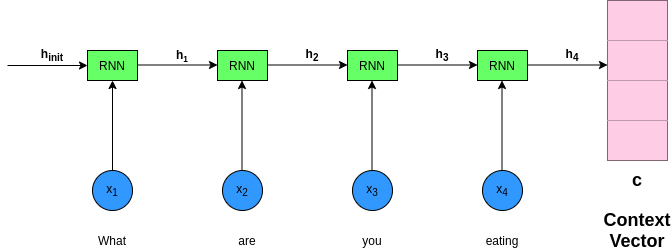</p>
<figcaption>Figure 3. An Encoder Architecture
</figcaption>
</figure>
</div>


From this figure, we can see how a context vector is calculated. In the first step, hidden state $h_1$ is calculated with the help of hidden states $x_1$ and $h_{init}$. In this way, the other hidden states $h_2$, $h_3$ and $h_4$ are calculated too. Here, the hidden state $h_4$ is the overall representation of the hidden states $h_1$, $h_2$ and $h_3$. This captures the contexts of all the words given as input at different time steps. Thus, it forms our embedding or the context vector as $c$. This context vector is fed as an input to the decoder which decodes it into the target sentence.




### 2. **Decoder**


The decoder architecture can be a RNN, LSTM or a GRU. Decoder uses the context vector and generates output sequence $(y_1, y_2, ..., y_T)$ based on the context vector and previous internal state. This means that $y_t$ is conditioned not only on $\pmb{h_{t-1}}$ but also on $y_{t-1}$ and $\pmb{c}$. Thus the hidden state of the decoder at time t is computed by,
\begin{equation}
\pmb{h_{(t)}} = f(\pmb{h_{(t-1)}}, y_{(t-1)}, \pmb{c})
\end{equation}

<div align="center">
<figure>


<p>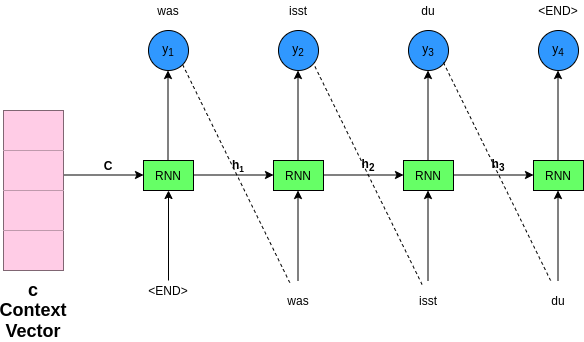</p>
<figcaption>Figure 4. A Decoder Architecture
</figcaption>
</figure>
</div>

From this figure we can understand the better representation of a decoder network.

Here, we can see that, initially, the input to the decoder network is context vector **$c$**. On every time steps $t$, the predicted output by the RNN cells $y_{t-1}$ are also fed as input to the next cell along with the previous hidden state $h_{t-1}$ and the current output prediction is obtained as $y_t$.

So, it is now clear that how a encoder decoder architecture work. It is necessary to know that decoder has to stop somewhere and finish the predictions. When the decoder predicts output words like: $\text{<EOS>}$, $\text{<SOS>}$ or $\text{<END>}$, this means that the sentence prediction is complete. The use of the end of sequence tags help decoder know that it has predicted a meanigful result from the context vector embeddings by the encoder.




### 3. **Teacher Forcing**

*To train encoder-decoder architecture, we can use teacher-forcing technique. In this technique, we pass the desired output instead of predicted output as the input to the next sequence in the decoder network. This is done to make the network learn quicker.*

<div align="center">
<figure>


<p>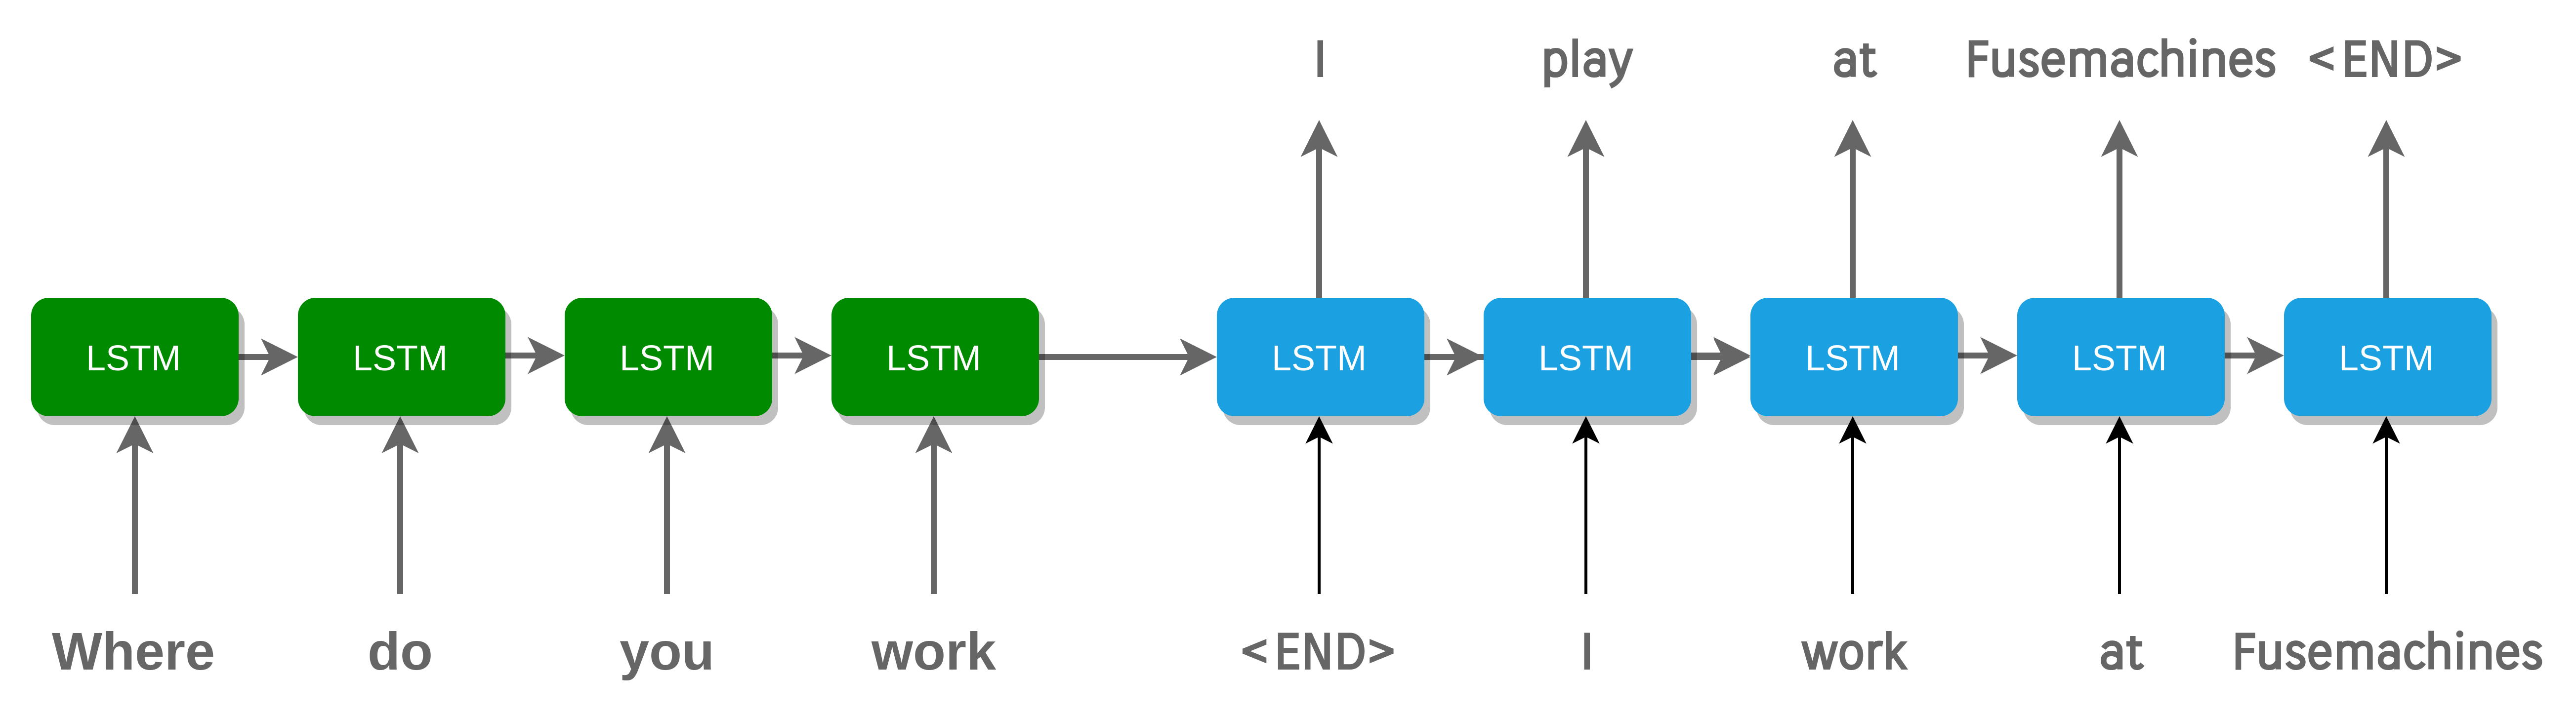</p>
<figcaption>Figure 5. Teacher Forcing
</figcaption>
</figure>
</div>

In the figure 5, we can see a question answering system. When we ask `Where do you work`, the machine replies sequentially. At first, it replies `I`, in the second timestep it replies `play`. But, `play` is not the verb we are looking for. So, in such cases while training a machine, we do not feed the output of current timestep as input to the next time step in teacher forcing technique. So, in this case instead of `play`, we send `work` as input to the next timestep and further predictions are made subsequently. In this way, the question answering machine replies `I work at Fusemachines` when the question `Where do you work` is asked.






# Seq2Seq with Fixed Context Vector (No Attention)

In a **traditional Seq2Seq model** (without attention), the **context vector** is a **fixed-size vector** that represents the entire input sequence. The encoder RNN processes the input sequence step by step, and its **final hidden state** is taken as the context vector. This single vector is then passed to the decoder as the initial hidden state (and sometimes input) to generate the output sequence.

We demonstrate how a Seq2Seq model translates **"I Love AI" → "J'aime l'IA"** using a **fixed-length context vector**.

## Step 1: Input Sentence Representation
Input: **"I Love AI"**

Each word is embedded into a vector:

- "I" → [0.2, 0.8, -0.5]  
- "Love" → [0.6, -0.1, 0.7]  
- "AI" → [-0.3, 0.9, 0.4]  
- `<EOS>` → [0.0, 0.0, 0.0]   *(special token for End Of Sequence)*

So input sequence =  
$
X = \{ [0.2, 0.8, -0.5], [0.6, -0.1, 0.7], [-0.3, 0.9, 0.4], [0.0, 0.0, 0.0] \}
$



## Step 2: Encoder RNN → Hidden States
Encoder (say hidden size = **4**) processes each step:

- \$(h_1 = f([0.2,0.8,-0.5]) = [0.1, 0.3, -0.2, 0.5]\$)
- \$(h_2 = f([0.6,-0.1,0.7], h_1) = [0.4, 0.1, 0.6, -0.3]\$)  
- \$(h_3 = f([-0.3,0.9,0.4], h_2) = [-0.2, 0.7, 0.3, 0.4]\$)  
- \$(h_4 = f([0.0,0.0,0.0], h_3) = [0.5, -0.1, 0.2, 0.6]\)$  

The **final hidden state** after `<EOS>` is the **context vector**:

$
\text{Context Vector } c = [0.5, -0.1, 0.2, 0.6]
$


## Step 3: Decoder Initialization
The **decoder** starts with the context vector \(c\) as its initial hidden state.

Decoder hidden state at start:  
$
s_0 = c = [0.5, -0.1, 0.2, 0.6]
$



## Step 4: Decoder Generates French Output
The decoder produces French tokens step by step:

1. Input `<start>` → output **"J'"**  
   - $(s_1 = g(s_0, <start>) = [0.3, -0.1, 0.6, 0.2]$)  
   - Prediction: "J'"

2. Next input "J'" → output **"aime"**  
   - \$(s_2 = g(s_1, "J'") = [-0.4, 0.2, 0.5, 0.7]\)$  
   - Prediction: "aime"

3. Next input "aime" → output **"l'IA"**  
   - $(s_3 = g(s_2, "aime") = [0.1, 0.5, -0.6, 0.4]$)  
   - Prediction: "l'IA"

4. Next input "l'IA" → output **`<EOS>`**  
   - $(s_4 = g(s_3, "l'IA") = [0.0, 0.0, 0.0, 0.0]$)  
   - Prediction: `<EOS>`  
   - **Translation stops here.**

Final output sequence: **"J'aime l'IA <EOS>"**


## Key Idea
- The **context vector** = `[0.5, -0.1, 0.2, 0.6]`  
- It compresses all meaning of `"I Love AI <EOS>"`.  
- The decoder relies entirely on this vector until it generates the `<EOS>` token.  
- `<EOS>` is crucial because it **signals the end of the sentence** for both encoding and decoding.  


## **Key Limitation**

- Since the entire input sequence must be compressed into **one fixed-size vector**, important details can be lost, especially for **long sentences**. This makes it harder for the decoder to produce accurate translations for longer input sequences, which later motivated the development of the **Attention Mechanism** which helps the decoder "look back" at different parts of the input sequence rather than relying only on one fixed vector.

.


Resources

https://www.analyticsvidhya.com/blog/2019/11/comprehensive-guide-attention-mechanism-deep-learning/

https://www.geeksforgeeks.org/nlp/encoder-decoder-models/
https://www.geeksforgeeks.org/machine-learning/seq2seq-model-in-machine-learning/